# Ejercicio 3: Planteo del método numérico

En el Ejercicio 2 obtuvimos la ecuación de Schrödinger no lineal para la amplitud compleja $a(x,t)$:

$$
i\frac{\partial a}{\partial t}
=
-\alpha\frac{\partial^2 a}{\partial x^2}
+g|a|^2a.
$$

El objetivo de este ejercicio es construir un método numérico para esta ecuación. Primero la llevamos a forma adimensional y luego la resolvemos en un dominio periódico usando un método pseudoespectral de Fourier.

La elección de condiciones periódicas no es un detalle menor: al tomar

$$
a(x+2\pi,t)=a(x,t),
$$

la base natural son los modos

$$
e^{ikx},
\qquad
k\in\mathbb Z.
$$

Esto permite calcular derivadas espaciales multiplicando cada modo por potencias de $ik$, y deja la no linealidad para ser calculada en espacio físico.

## 3(a) Adimensionalización

El dominio físico tiene longitud $2\pi L$. Introducimos la coordenada adimensional

$$
x'=\frac{x}{L},
$$

por lo que el dominio pasa a ser

$$
0\leq x'<2\pi.
$$

Además introducimos un tiempo adimensional

$$
t'=\frac{t}{t_0}.
$$

Las derivadas se transforman como

$$
\frac{\partial}{\partial t}=\frac{1}{t_0}\frac{\partial}{\partial t'},
\qquad
\frac{\partial^2}{\partial x^2}=\frac{1}{L^2}\frac{\partial^2}{\partial x'^2}.
$$

Reemplazando en la ecuación dimensional,

$$
i\frac{1}{t_0}\frac{\partial a}{\partial t'}
=-\alpha\frac{1}{L^2}\frac{\partial^2 a}{\partial x'^2}+g|a|^2a.
$$

Multiplicando por $t_0$:

$$
i\frac{\partial a}{\partial t'}
=-\frac{\alpha t_0}{L^2}\frac{\partial^2 a}{\partial x'^2}+gt_0|a|^2a.
$$

Elegimos

$$
t_0=\frac{L^2}{\alpha},
$$

para que el coeficiente del término dispersivo sea uno. Entonces queda

$$
i\frac{\partial a}{\partial t'}=-\frac{\partial^2 a}{\partial x'^2}+\beta |a|^2a,
$$

donde

$$
\beta=gt_0=\frac{gL^2}{\alpha}.
$$

En lo que sigue omitimos las primas y resolvemos la ecuación adimensional

$$
i a_t=-a_{xx}+\beta |a|^2a.
$$

Despejando la derivada temporal:

$$
a_t=i a_{xx}-i\beta |a|^2a.
$$


## 3(b) Integrador pseudoespectral con Euler

Trabajamos en el dominio periódico adimensional

$$
0\le x<2\pi,
\qquad
a(x+2\pi,t)=a(x,t).
$$

Usamos una grilla uniforme con $N=128$ puntos. En Fourier,

$$
a(x,t)=\sum_k a_k(t)e^{ikx},
$$

y por lo tanto

$$
a_{xx}\longleftrightarrow -k^2 a_k.
$$

La estrategia pseudoespectral es:

1. transformar $a(x,t)$ a Fourier;
2. calcular $a_{xx}$ multiplicando por $-k^2$;
3. volver a espacio real;
4. calcular la no linealidad $|a|^2a$ en espacio real;
5. transformar esa no linealidad a Fourier y aplicar de-aliasing;
6. avanzar con Euler explícito.

El de-aliasing se aplica al término no lineal, no a la condición inicial. La razón es que el producto cúbico $|a|^2a$ genera convoluciones entre modos. En una grilla finita, si esas convoluciones producen modos no resolubles, pueden plegarse como modos bajos falsos. El filtrado evita interpretar aliasing numérico como transferencia física de energía entre modos.

El paso de Euler es

$$
a^{n+1}=a^n+\Delta t\,F(a^n),
$$

con

$$
F(a)=ia_{xx}-i\beta |a|^2a.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros globales del problema discreto.
N = 128
L_adim = 2*np.pi
x = L_adim*np.arange(N)/N
dx = L_adim/N

# En el dominio adimensional 0 <= x < 2*pi, los números de onda son enteros.
k = np.fft.fftfreq(N, d=1/N)
kmax_dealias = N//4


def dealias(f_fft):
    """Anula los modos por encima de la regla indicada por la guía.

    En este TP se toma como máximo resoluble k_max=N/4. Para N=128,
    esto deja activos los modos |k| < 32 aproximadamente.
    """
    f_fft = f_fft.copy()
    f_fft[np.abs(k) >= kmax_dealias] = 0.0
    return f_fft


def energia(a):
    """Energía discreta E = mean(|a|^2)."""
    return np.mean(np.abs(a)**2)


def modos_activos(a, tol=1e-10):
    """Devuelve los modos de Fourier cuyo módulo supera una tolerancia."""
    ahat = np.fft.fft(a)/N
    return np.array(sorted(k[np.abs(ahat) > tol].astype(int)))


def rhs_pseudoespectral(a, beta):
    """Campo F(a)=a_t para la NLS adimensional.

    La ecuación es
        i a_t = -a_xx + beta |a|^2 a,
    por lo tanto
        a_t = i a_xx - i beta |a|^2 a.
    """
    # Derivada segunda calculada espectralmente.
    ahat = np.fft.fft(a)
    a_xx = np.fft.ifft(-(k**2)*ahat)

    # No linealidad calculada en espacio real y luego dealiasing en Fourier.
    nonlinear = np.abs(a)**2*a
    nonlinear_hat = dealias(np.fft.fft(nonlinear))
    nonlinear_dealias = np.fft.ifft(nonlinear_hat)

    return 1j*a_xx - 1j*beta*nonlinear_dealias


def paso_euler(a, dt, beta):
    """Un paso de Euler explícito."""
    return a + dt*rhs_pseudoespectral(a, beta)


def condicion_bicromatica(amplitud=1.0):
    """Condición inicial con modos k=1 y k=2 de igual amplitud."""
    return amplitud*(np.exp(1j*x) + np.exp(2j*x))


## 3(c) Condición bicromática y modos encendidos

Tomamos una condición inicial perfectamente bicromática con modos $k=1$ y $k=2$:

$$
a(x,0)=A e^{ix}+A e^{2ix}.
$$

Esta condición inicial ya está construida con modos resolubles de la grilla, por lo que no necesita de-aliasing. El filtrado se usa después, cuando se calcula el término no lineal.

El término no lineal tiene la estructura

$$
|a|^2a=a^*aa.
$$

En Fourier, esto produce la regla de selección

$$
k=-k_1+k_2+k_3,
$$

o equivalentemente

$$
k+k_1-k_2-k_3=0.
$$

Si inicialmente solo están activos los modos $1$ y $2$, entonces después de evaluar una vez la no linealidad pueden aparecer combinaciones

$$
k=-p+q+r,
\qquad
p,q,r\in\{1,2\}.
$$

Esto produce los modos

$$
k\in\{0,1,2,3\}.
$$

Como $1$ y $2$ ya estaban presentes, los modos nuevos tras un paso son $0$ y $3$.

In [2]:
# Parámetros para el experimento de activación de modos.
beta = 1.0
dt = 1e-3
A = 1.0

a0 = condicion_bicromatica(amplitud=A)
a1 = paso_euler(a0, dt, beta)
a2 = paso_euler(a1, dt, beta)

print("Modos activos inicialmente:", modos_activos(a0))
print("Modos activos luego de 1 paso:", modos_activos(a1))
print("Modos activos luego de 2 pasos:", modos_activos(a2))
print("E(0) =", energia(a0))
print("E(1 paso) =", energia(a1))
print("E(2 pasos) =", energia(a2))


Modos activos inicialmente: [1 2]
Modos activos luego de 1 paso: [0 1 2 3]
Modos activos luego de 2 pasos: [-2 -1  0  1  2  3  4  5]
E(0) = 2.0
E(1 paso) = 2.0000669999999996
E(2 pasos) = 2.000134005773136


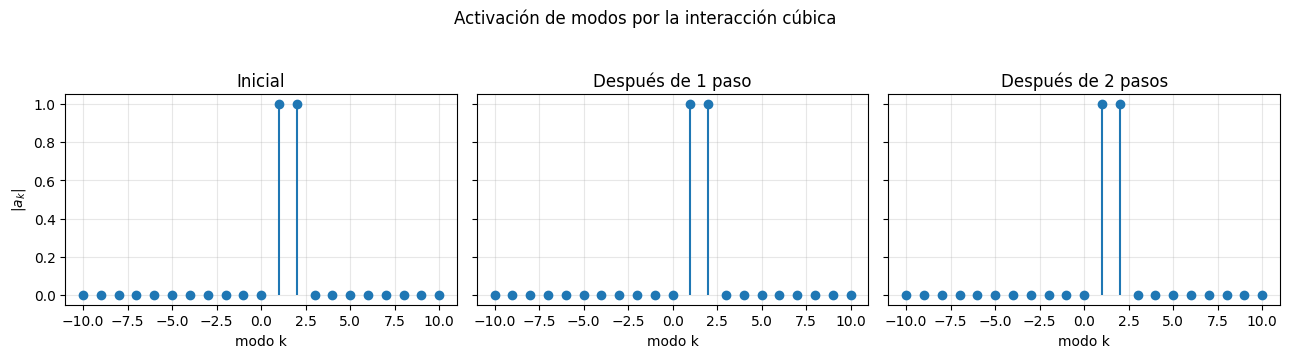

In [3]:
# Visualización del espectro espacial después de 0, 1 y 2 pasos.
def espectro_1d(a):
    return np.abs(np.fft.fft(a)/N)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, a, titulo in zip(
    axes,
    [a0, a1, a2],
    ["Inicial", "Después de 1 paso", "Después de 2 pasos"]
):
    amp = espectro_1d(a)
    # Mostramos solo una ventana de modos chicos, que son los relevantes acá.
    modos = np.arange(-10, 11)
    indices = [np.where(k == m)[0][0] for m in modos]
    ax.stem(modos, amp[indices], basefmt=" ")
    ax.set_title(titulo)
    ax.set_xlabel("modo k")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"$|a_k|$")
fig.suptitle("Activación de modos por la interacción cúbica", y=1.04)
plt.tight_layout()
plt.show()


### Lectura del resultado

Después de un paso temporal, los modos activos esperados son


$\{0,1,2,3\}.$


Esto coincide con la regla de selección de cuatro ondas


$k=-k_1+k_2+k_3.$


En el segundo paso, la no linealidad vuelve a combinar los modos ya encendidos. En principio, si después del primer paso el soporte está en


$\{0,1,2,3\},$


la regla de selección permite combinaciones dentro del intervalo


$k\in[-3,6].$


Sin embargo, los extremos de ese intervalo aparecen a orden muy alto en $\Delta t$, porque requieren combinar modos que recién fueron generados en el paso anterior. Con una tolerancia numérica razonable, lo que se observa claramente después del segundo paso es


$k\in\{-2,-1,0,1,2,3,4,5\}.$


La idea importante es que cada evaluación de la no linealidad ensancha el soporte espectral. Si idealmente los modos activos ocupan un intervalo $[m,M]$, la interacción cúbica puede generar


$[2m-M,\,2M-m].$


Partiendo de $[1,2]$, la estimación algebraica sería


$[1,2]\to[0,3]\to[-3,6]\to[-12,15]\to[-39,42].$


Como el método conserva únicamente los modos resolubles hasta aproximadamente $|k|<32$, esta estimación sugiere que en unos cuatro pasos de activación no lineal todos los modos resolubles pueden estar permitidos por la regla de selección. En una simulación concreta, algunos de esos modos pueden tener amplitudes extremadamente pequeñas, por lo que la respuesta observable depende de la tolerancia elegida para declarar un modo como activo.
